$$
\begin{split}
D_{kl}(P\|Q)&=?\\
P(x)&=\mathcal N(\mu_1,\sigma_1)+\mathcal N(\mu_2, \sigma_2)\\
Q(x)&=\mathcal N(\mu_q=?, \sigma_q=?)
\end{split}
$$

In [ ]:
import torch
import torch.nn.functional as F
from matplotlib import animation
import matplotlib.pyplot as plt
plt.rcParams['figure.dpi'] = 120

## $P(x)$

In [ ]:
mu1, sigma1 = -5, 1
mu2, sigma2 = 10, 1

In [ ]:
gaussian1 = torch.distributions.Normal(mu1, sigma1)
gaussian2 = torch.distributions.Normal(mu2, sigma2)

Text(0.5, 1.0, '$\\mu_2$=10,$\\sigma_2$=1')

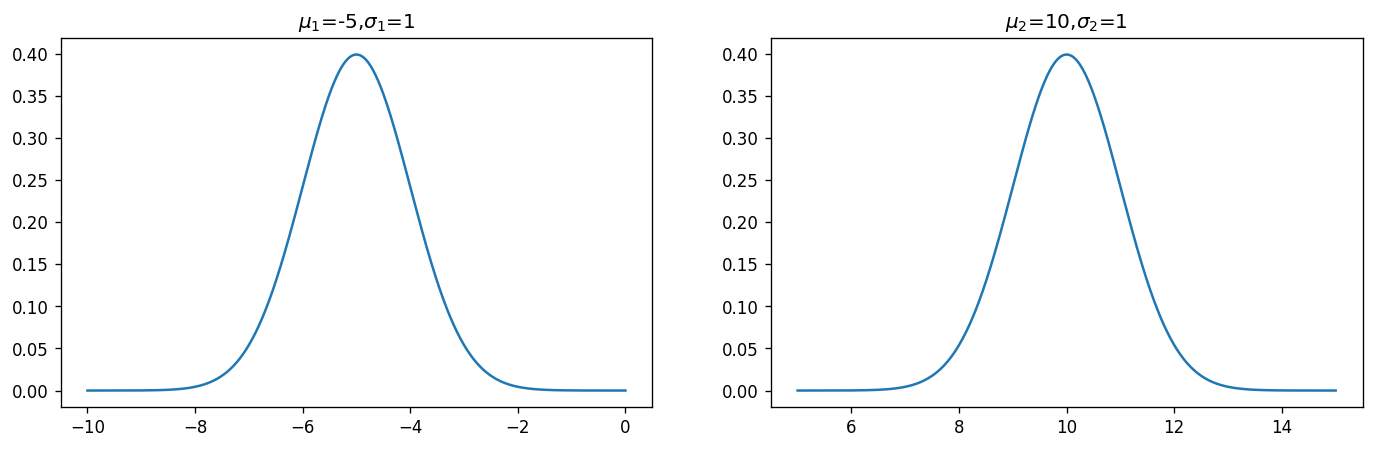

In [ ]:
plt.figure(figsize=(14, 4))
x = torch.linspace(mu1-5*sigma1, mu1+5*sigma1, 1000)
plt.subplot(1, 2, 1)
plt.plot(x.numpy(), gaussian1.log_prob(x).exp().numpy())
plt.title(rf'$\mu_1$={mu1},$\sigma_1$={sigma1}')

x = torch.linspace(mu2-5*sigma2, mu2+5*sigma2, 1000)
plt.subplot(1, 2, 2)
plt.plot(x.numpy(), gaussian2.log_prob(x).exp().numpy())
plt.title(rf'$\mu_2$={mu2},$\sigma_2$={sigma2}')

$$
\exp^{\log x}=x
$$

Text(0.5, 1.0, '$P(X)$')

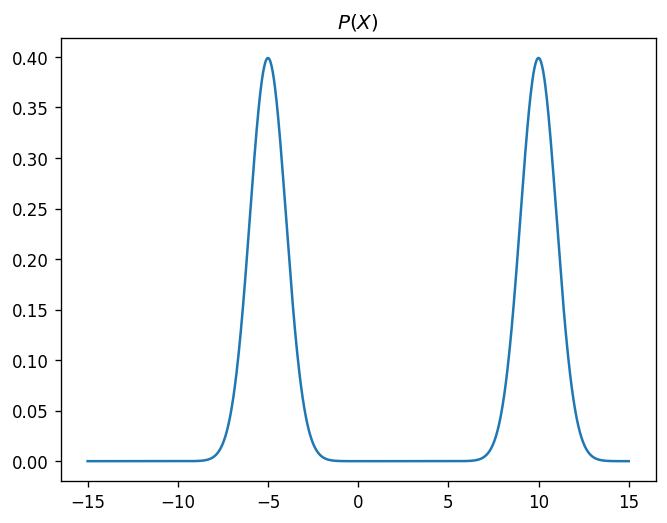

In [ ]:
x = torch.linspace(-mu1-mu2-5*sigma1-5*sigma2, mu1+mu2+5*sigma1+5*sigma2, 1000)
px = gaussian1.log_prob(x).exp() + gaussian2.log_prob(x).exp()
plt.plot(x.numpy(), px.numpy())
plt.title('$P(X)$')

## Q(x)

In [ ]:
mu = torch.tensor([0.0])
sigma = torch.tensor([1.0])

Text(0.5, 1.0, '$Q(X)$')

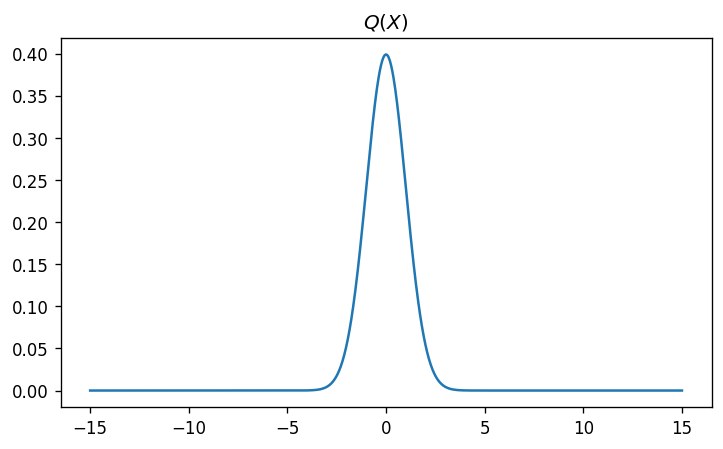

In [ ]:
plt.figure(figsize=(7, 4))
x = torch.linspace(-mu1-mu2-5*sigma1-5*sigma2,mu1+mu2+5*sigma1+5*sigma2,1000)
Q = torch.distributions.Normal(mu, sigma) # this should approximate P, eventually :-)
qx = Q.log_prob(x).exp()
plt.plot(x.numpy(),qx.detach().numpy())
plt.title('$Q(X)$')

## kl-div

In [ ]:
x = torch.linspace(-mu1-mu2-5*sigma1-5*sigma2,
                   mu1+mu2+5*sigma1+5*sigma2,
                   1000)
px = gaussian1.log_prob(x).exp() + gaussian2.log_prob(x).exp()
print(px.shape)

`F.kl_div`:
- input: Tensor of arbitrary shape in log-probabilities. : q(x)
- target: Tensor of the same shape as input. : p(x)
    - log_target: default `False`

In [ ]:
qx = Q.log_prob(x)
F.kl_div(qx, px, reduction='batchmean')

tensor(2.0812)

In [ ]:
qx = Q.log_prob(x)
F.kl_div(qx, px, reduction='batchmean')

tensor(2.0812)

## kl-div as the loss

In [ ]:
x = torch.linspace(-mu1-mu2-5*sigma1-5*sigma2,
                   mu1+mu2+5*sigma1+5*sigma2,
                   1000)
px = gaussian1.log_prob(x).exp() + gaussian2.log_prob(x).exp()

In [ ]:
def optimize_loss(px, muq, sigmaq):
    
    mu = torch.tensor([muq], requires_grad=True)
    sigma = torch.tensor([sigmaq], requires_grad=True)
    
    opt = torch.optim.Adam([mu, sigma])
    
    all_mu = []
    all_sigma = []
    loss_val = []
    all_qx = []
    
    for i in range(10000):
        
        Q = torch.distributions.Normal(mu, sigma)
        qx = Q.log_prob(x)
        
        loss = F.kl_div(qx, px, reduction='batchmean')
        
        opt.zero_grad()
        loss.backward()
        opt.step()
        
        loss_val.append(loss.detach().numpy())
        all_mu.append(mu.data.numpy()[0])
        all_qx.append(qx.exp().detach().numpy())
        
        if i % 1000 == 0:
            print(i, loss_val[-1])
            
    plt.subplot(1, 2, 1)
    plt.plot(loss_val)
    plt.title('loss')
    
    plt.subplot(1, 2, 2)
    plt.plot(all_mu)
    plt.title('$\mu$')
    return mu.data.numpy()[0], sigma.data.numpy()[0], all_qx

<>:37: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
<>:37: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
/tmp/ipykernel_21220/969611367.py:37: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
  plt.title('$\mu$')


0 2.081249
1000 0.7304135
2000 0.4642204
3000 0.34432054
4000 0.27543005
5000 0.23109896
6000 0.20085067
7000 0.1796072
8000 0.16454785
9000 0.1539281


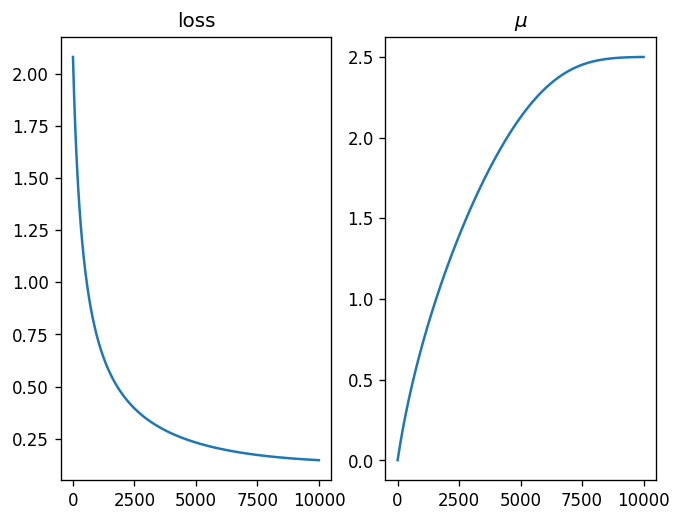

In [ ]:
mu, sigma, all_qx = optimize_loss(px, 0., 1.)

In [ ]:
len(all_qx)

10000

In [ ]:
mu

np.float32(2.4993849)

## visualization

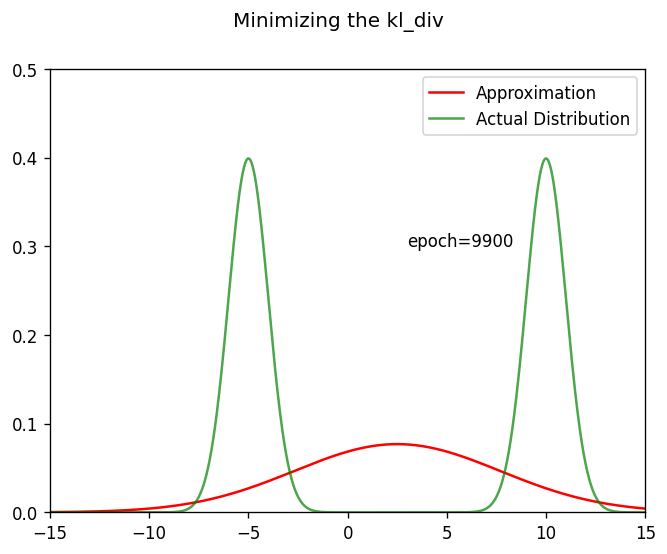

In [ ]:
fig = plt.figure() 
ax = plt.axes(xlim=(x.min(),x.max()), ylim=(0,0.5)) 
text = ax.text(3,0.3,0)
line1, = ax.plot([], [], color = "r")
line2, = ax.plot([], [], color = "g",alpha=0.7)


def animate(i):    
    if i<75:
        line1.set_data(x.numpy(),all_qx[i*50])
        text.set_text(f'epoch={i*50}')
        line2.set_data(x.numpy(),px.numpy())
    else:
        line1.set_data(x.numpy(),all_qx[i*100])
        text.set_text(f'epoch={i*100}')
        line2.set_data(x.numpy(),px.numpy())

    return [line1,line2]

ani = animation.FuncAnimation(fig,animate,frames=100 ,interval=200, blit=True)
fig.suptitle('Minimizing the kl_div')
ax.legend(['Approximation','Actual Distribution'])
# save the animation as gif
ani.save('kl_div.gif', writer='pillow', fps=10) 

### mse loss

In [ ]:
def optimize_loss(px, muq, sigmaq):
    
    mu = torch.tensor([muq], requires_grad=True)
    sigma = torch.tensor([sigmaq], requires_grad=True)
    
    opt = torch.optim.Adam([mu, sigma])
    
    all_mu = []
    all_sigma = []
    loss_val = []
    all_qx = []
    
    for i in range(10000):
        
        Q = torch.distributions.Normal(mu, sigma)
#         qx = Q.log_prob(x)
#         loss = F.kl_div(qx, px)
        qx = Q.log_prob(x).exp()
        loss = F.mse_loss(qx, px)
        opt.zero_grad()
        loss.backward()
        opt.step()
        
        loss_val.append(loss.detach().numpy())
        all_mu.append(mu.data.numpy()[0])
        
        all_qx.append(qx.detach().numpy())
        
        if i % 1000 == 0:
            print(i, loss_val[-1])
            
    plt.subplot(1, 2, 1)
    plt.plot(loss_val)
    plt.title('loss')
    
    plt.subplot(1, 2, 2)
    plt.plot(all_mu)
    plt.title('$\mu$')
    return mu.data.numpy()[0], sigma.data.numpy()[0], all_qx

<>:38: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
<>:38: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
/tmp/ipykernel_21220/3114138457.py:38: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
  plt.title('$\mu$')


0 0.028145004
1000 0.020257149
2000 0.015502927
3000 0.013607614
4000 0.010931814
5000 0.009393812
6000 0.009393757
7000 0.009393757
8000 0.009393757
9000 0.009393757


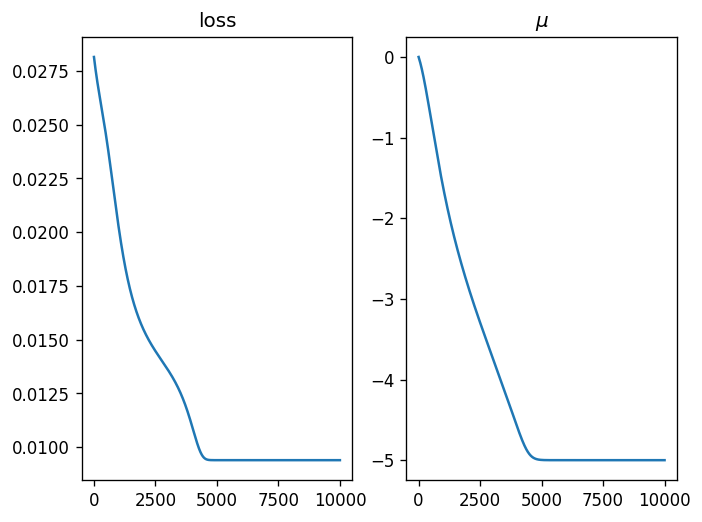

In [ ]:
mu, sigma, all_qx = optimize_loss(px, 0., 1.)

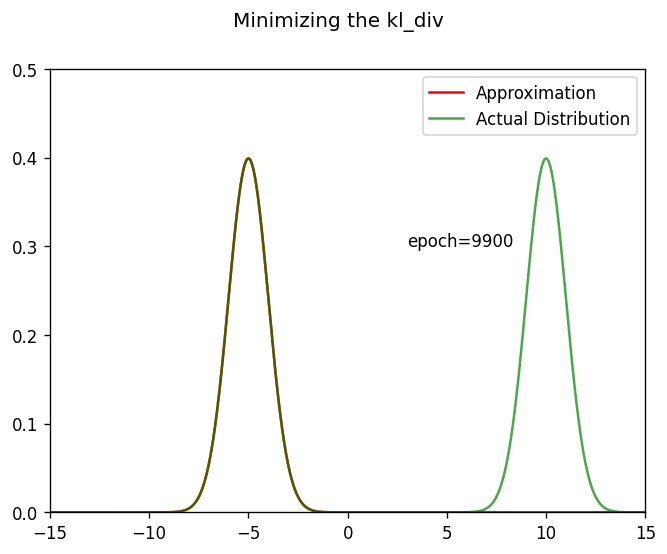

In [ ]:
fig = plt.figure() 
ax = plt.axes(xlim=(x.min(),x.max()), ylim=(0,0.5)) 
text = ax.text(3,0.3,0)
line1, = ax.plot([], [], color = "r")
line2, = ax.plot([], [], color = "g",alpha=0.7)


def animate(i):    
    if i<75:
        line1.set_data(x.numpy(),all_qx[i*50])
        text.set_text(f'epoch={i*50}')
        line2.set_data(x.numpy(),px.numpy())
    else:
        line1.set_data(x.numpy(),all_qx[i*100])
        text.set_text(f'epoch={i*100}')
        line2.set_data(x.numpy(),px.numpy())

    return [line1,line2]

ani = animation.FuncAnimation(fig,animate,frames=100 ,interval=200, blit=True)
fig.suptitle('Minimizing the kl_div')
ax.legend(['Approximation','Actual Distribution'])
# save the animation as gif
ani.save('mse.gif', writer='pillow', fps=10) 